Load the EDA dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_csv('customer_churn_processed_eda.csv')
df.head()

,CustomerTenure,TotalRevenue,OrderFrequency,TotalProductSubCategories,MostPurchasedCategory,AvgDaysBetweenOrders,RecencyRatio,ChurnLabel
0,1105,9.017967,1.386294,6,1,417.0,0.499248,1
1,1109,8.761688,1.386294,7,1,530.0,0.088425,0
2,1117,9.001474,1.386294,3,1,389.0,0.626722,1
3,1126,9.004581,1.386294,5,1,431.0,0.476364,1
4,1101,9.011525,1.386294,4,1,414.0,0.505012,1


Add Recency,Frequency , Monetary features only to make the clusters in a better way

In [3]:
rfm_features = df[['RecencyRatio','OrderFrequency', 'TotalRevenue']]
scaler = StandardScaler()

In [4]:
# Fit and transform the rfm features
rfm_scaled = scaler.fit_transform(rfm_features)


In [5]:
# Choose the correct k value using elbow method
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

In [6]:
wcss

[57357.00000000009,
 19362.27381015663,
 13092.587916734275,
 7942.048569924782,
 4615.738705508295,
 3797.622736469746,
 3150.7608931164086,
 2451.2823695152465,
 1985.527223458866,
 1977.3024253333274]

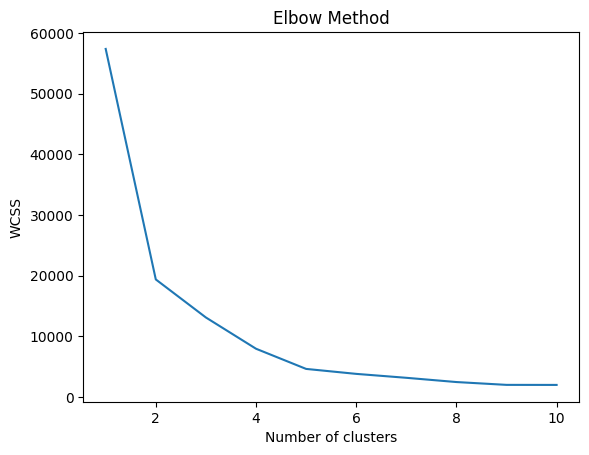

In [7]:
# plot the elbow curve
plt.plot(range(1,11),wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [28]:
# confirms this k value using silhouette score
silhouette_coefficients=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(rfm_scaled)
    score=silhouette_score(rfm_scaled,kmeans.labels_)
    silhouette_coefficients.append(score)


In [29]:
silhouette_coefficients

[0.6527607348288524,
 0.6514152614888438,
 0.6433392574668693,
 0.6331406175222434,
 0.6984403943164306,
 0.6634723948261105,
 0.6482870180636117,
 0.6680674961500579,
 0.6591240346545139]

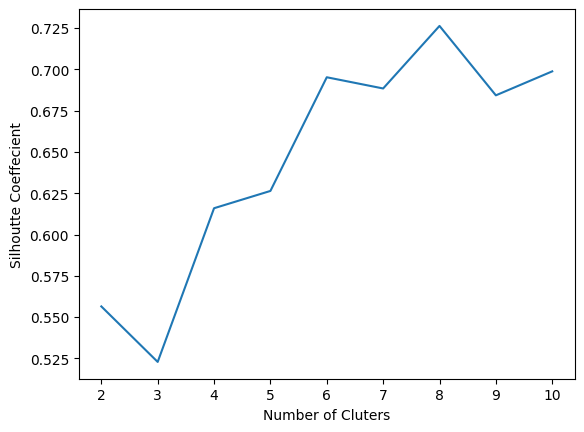

In [10]:
# plot the silhouette scores
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("Number of Cluters")
plt.ylabel("Silhoutte Coeffecient")
plt.show()

In [9]:
# from elbow method and silhouette score we can conclude that the best k value is 5
kmeans = KMeans(n_clusters=5,init="k-means++")

In [10]:
# now take the rfm_scaled feature  to fit the model and predict the clusters
rfm_pred = kmeans.fit_predict(rfm_scaled)

In [11]:
rfm_pred

array([1, 1, 1, ..., 2, 2, 2], shape=(19119,), dtype=int32)

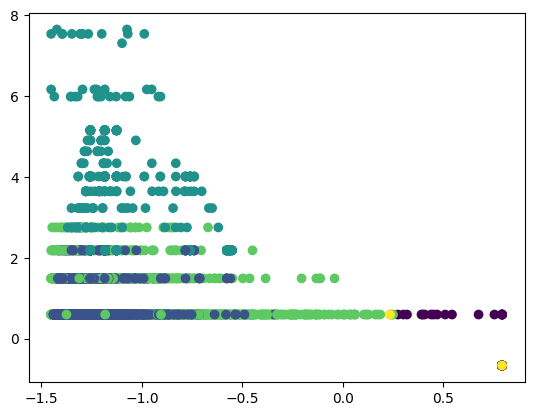

In [12]:
# plot the graph to see the clusters
plt.scatter(rfm_scaled[:,0],rfm_scaled[:,1],c=rfm_pred)

In [15]:
# Add Cluster column to the dataframe
df['Cluster'] = rfm_pred

In [16]:
print(df['Cluster'].value_counts())

Cluster
0    7501
1    5113
2    4148
4    1834
3     523
Name: count, dtype: int64


In [17]:
df.groupby('Cluster')[['TotalRevenue', 'OrderFrequency']].mean()

,TotalRevenue,OrderFrequency
Cluster,,
0,3.623600,0.693147
1,8.307076,1.163888
2,7.158104,0.693147
3,10.928866,2.090339
4,4.670666,1.184870


In [18]:
# Name the clusters and add as a feature to the dataframe
cluster_labels = {
    0: 'Dormant Customers',          # low revenue, low frequency
    1: 'Loyal Customers',            # high revenue, decent frequency
    2: 'At Risk High Spenders',      # good revenue but low frequency
    3: 'High Value Customers',       # top tier (very high-high)
    4: 'Frequent Low Spenders'       # comes often but spends less
}

df['ClusterLabel'] = df['Cluster'].map(cluster_labels)  

In [19]:
df.head()

,CustomerTenure,TotalRevenue,OrderFrequency,TotalProductSubCategories,MostPurchasedCategory,AvgDaysBetweenOrders,RecencyRatio,ChurnLabel,Cluster,ClusterLabel
0,1105,9.017967,1.386294,6,1,417.0,0.499248,1,1,Loyal Customers
1,1109,8.761688,1.386294,7,1,530.0,0.088425,0,1,Loyal Customers
2,1117,9.001474,1.386294,3,1,389.0,0.626722,1,1,Loyal Customers
3,1126,9.004581,1.386294,5,1,431.0,0.476364,1,1,Loyal Customers
4,1101,9.011525,1.386294,4,1,414.0,0.505012,1,1,Loyal Customers


In [20]:
df['ClusterLabel'].value_counts()

ClusterLabel
Dormant Customers        7501
Loyal Customers          5113
At Risk High Spenders    4148
Frequent Low Spenders    1834
High Value Customers      523
Name: count, dtype: int64

In [21]:
# Save this dataframe into a csv file to use it in the next notebook for classification model
df.to_csv('customer_churn_clustered.csv', index=False)

In [22]:
# Save the dataframe , kmeans segmentations and the scaled features using joblib
import joblib
loaded_df = joblib.dump(df,'Clustered_Customer_Churn_DataFrame.joblib')
loaded_features = joblib.dump(scaler , 'Clustered_Features.joblib')
loaded_kmeans = joblib.dump(kmeans , 'Clustered_KMeans_Model.joblib')
loaded_df , loaded_kmeans, loaded_features


(['Clustered_Customer_Churn_DataFrame.joblib'],
 ['Clustered_KMeans_Model.joblib'],
 ['Clustered_Features.joblib'])